In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# datos
length = 20.0
num_points = 100
num_steps = 1000
alpha_macro = 0.01 # primer material
alpha_micro = 0.001 # primer material

In [16]:
# modelo macroscópico
def macroscopic_model(T, alpha, num_steps):
    # Paso del tiempo
    dt = 0.01
    dx = length / num_points # Espaciado 
    T_new = np.copy(T)

    for _ in range(num_steps):
        for i in range(1, len(T) - 1):
            T_new[i] += alpha * (T[i - 1] - 2 * T[i] + T[i + 1]) * dt / (dx ** 2)
        T[:] = T_new
    return T

In [17]:
# modelo macroscópico
def microscopic_model(T, alpha, num_steps):
    # Paso del tiempo
    dt = 0.001
    dx = length / (num_points * 10)
    T_new = np.copy(T)

    for _ in range(num_steps):
        for i in range(1, len(T) - 1):
            T_new[i] += alpha * (T[i - 1] - 2 * T[i] + T[i + 1]) * dt / (dx ** 2)
        T[:] = T_new
    return T

In [18]:

# Inicializar la temperatura en la varilla (condición inicial)
initial_temperature = np.zeros(num_points)
initial_temperature[:num_points//2] = 100.0  # Temperatura inicial en la mitad izquierda
initial_temperature[num_points//2:] = 0.0    # Temperatura inicial en la mitad derecha


In [19]:
# Simulación secuencial de múltiples escalas

for step in range(num_steps):
    # Modelo macroscópico para la primera mitad de la varilla
    temperature_macro = macroscopic_model(initial_temperature, alpha_macro, 10)

    # Modelo microscópico para la segunda mitad de la varilla
    temperature_micro = microscopic_model(initial_temperature, alpha_micro, 100) 

    # Combinar resultados de ambos modelos
    combined_temperature = np.concatenate((temperature_macro, temperature_micro))


for step in range(num_steps):
    # Modelo macroscópico para la primera mitad de la varilla
    temperature_macro = macroscopic_model(initial_temperature[:num_points//2], alpha_macro, 10) # material 1

    # Modelo microscópico para la segunda mitad de la varilla
    temperature_micro = microscopic_model(initial_temperature[num_points//2:], alpha_micro, 100) # material 2

    # Combinar resultados de ambos modelos
    combined_temperature = np.concatenate((temperature_macro, temperature_micro))


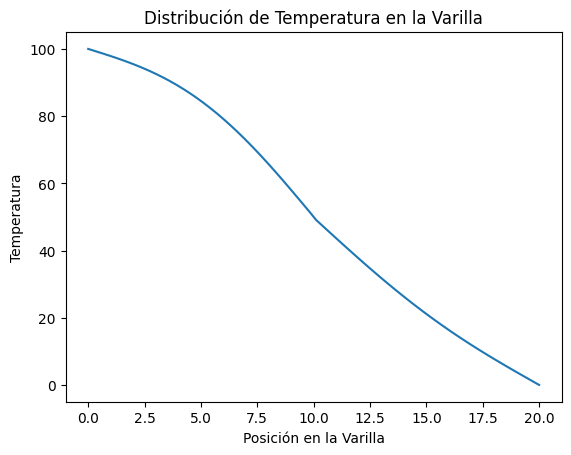

In [21]:
# Visualización de la distribución de temperatura final
plt.plot(np.linspace(0, length, num_points), combined_temperature)
plt.xlabel('Posición en la Varilla')
plt.ylabel('Temperatura')
plt.title('Distribución de Temperatura en la Varilla (1)')
plt.show()

## Preguntas

1) ¿En qué se diferencia el modelo macroscópico del modelo microscópico en este escenario?<br>
La mayor diferencia entre ambos modelos es el scope de la varilla que utilizan. En el modelo macroscópico usa una medida 10 veces mayor en la varilla que el microscópico. Otra gran diferencia son los coeficientes de difusión térmica que se utizan en cada modelo, siguiendo el patrón de trabajo macro y micro respectivamente.
<br><br>
2) ¿Cuáles son las condiciones de contorno del modelo microscópico y cómo las determina el modelo macroscópico?<br>
En el caso del modelo microscópico las condiciones de contorno son determinadas por el modelo macroscópico debido a que el modelo microscópico se obtiene a partir de los resultados calculados por el modelo macroscópico, solo que este utliza secciones mucho más pequeñas tal como fue mencionado anteriormente. 
<br><br>
3) ¿Cómo adaptaría este modelo multiescala si la varilla estuviera compuesta por más de dos materiales diferentes?<br>
Primero se tendría que dividir el modelo en la cantidad de materiales que conforman a la varilla y hacer un modelo por cada uno de ellos. Luego se crearían las interfaces y las transiciones entre interfases. Luego se integrarían los modelos para que todos trabajen con las mismas escalas y se realizaría la simulación y la visualización de los resultados. 